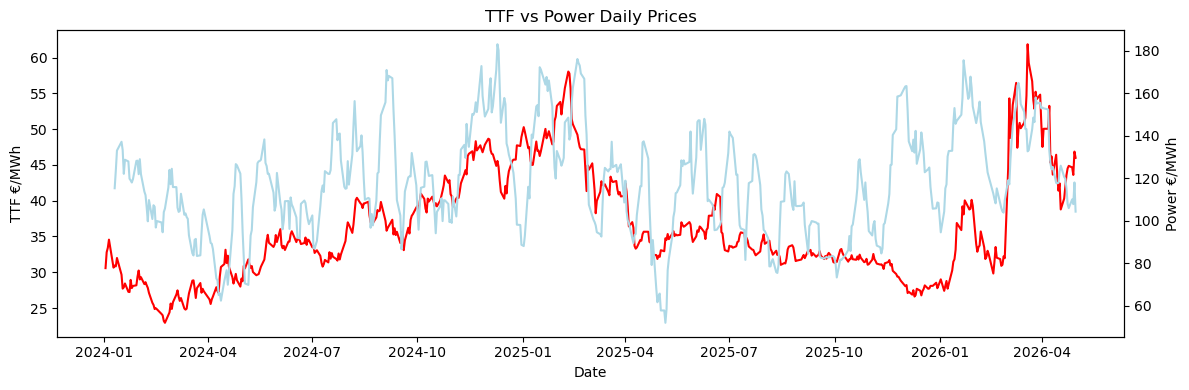

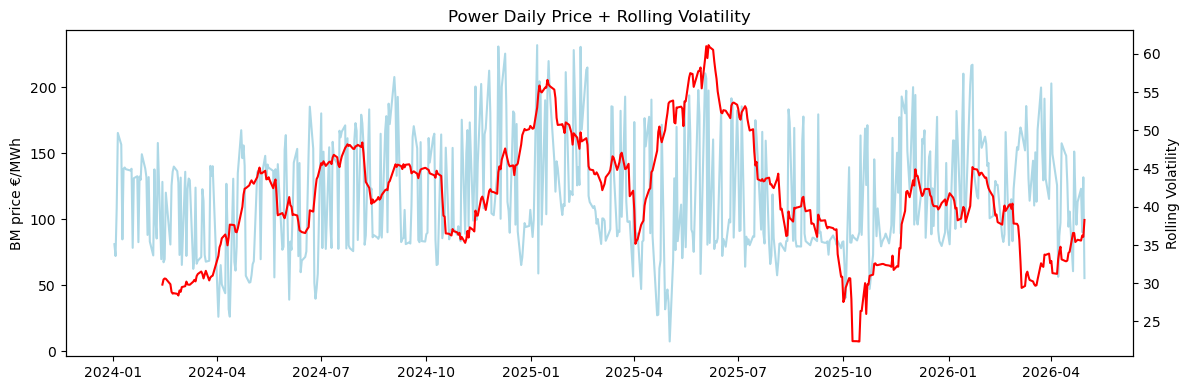

                            OLS Regression Results                            
Dep. Variable:                  power   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     38.17
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.22e-09
Time:                        22:23:28   Log-Likelihood:                -3028.7
No. Observations:                 585   AIC:                             6061.
Df Residuals:                     583   BIC:                             6070.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         64.0232      8.896      7.197      0.0

In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt


# !pip install yfinance
# import yfinance as yf

# -------------------- 1 : TTF csv from yahoo finance --------------------

# ttf_daily = yf.download("TTF=F", start="2022-01-01", end="2026-05-01")
# ttf_daily.to_csv("TTF/ttf_daily.csv")
TTF = pd.read_csv("TTF/ttf_daily.csv")
TTF = TTF.replace("Ticker", np.nan)
TTF = TTF.dropna()

ttf = pd.DataFrame()
ttf["date"] = pd.to_datetime(TTF["Price"])
ttf["ttf"] = pd.to_numeric(TTF["Close"])

daily_ttf = ttf.copy()
# I saved this copy since I will need to run an OLS on daily data


# -------------------- 2 : BM csv from TERNA --------------------


files = glob.glob("MB/*.xlsx")
frames = []

for i in files:
    A = pd.read_excel(i)
    frames.append(A)

MB = pd.concat(frames)
MB = MB.replace("SUD", np.nan)
MB = MB.dropna()
MB = MB.drop(index=0).reset_index(drop=True)
BM = pd.DataFrame()

BM["datetime"] = pd.to_datetime(MB["Riepilogo Mensile Quarto Orario"].str.rsplit(":", n=1).str[0], format = "%d/%m/%Y %H:%M")
BM["volume"] = pd.to_numeric(MB["Riepilogo Mensile Quarto Orario.2"])
BM["sign"] = MB["Riepilogo Mensile Quarto Orario.3"]
BM["power"] = pd.to_numeric(MB["Riepilogo Mensile Quarto Orario.8"])
BM = BM.drop(index=0).reset_index(drop=True)


# -------------------- 3 : merge on quarter hours --------------------


# to merge with ttf, let's assume ttf constant throughout the whole day

BM["date"] = BM["datetime"].dt.date
BM["date"] = pd.to_datetime(BM["date"])
ttf = ttf.loc[ttf.index.repeat(96)].copy()
ttf = ttf.reset_index(drop = True)

gaspower = pd.DataFrame()
gaspower = pd.merge(BM, ttf, on = "date", how = "left")
gaspower = gaspower.dropna()

# ttf since 2022
# bm since 2024
# due to 2022 market's singularity, 
# I decided to focus only on more recent data


# -------------------- 4 : plots --------------------


power_daily = gaspower.groupby("date")["power"].median()
rolling_vol = power_daily.rolling(window=30).std()
power_smooth = power_daily.rolling(window=7).mean()

# ttf

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(gaspower["date"], gaspower["ttf"], color = "red")
ax2 = ax.twinx() #
ax2.plot(power_smooth.index, power_smooth.values, color="lightblue") #
ax.set_xlabel("Date")
ax.set_ylabel("TTF €/MWh")
ax2.set_ylabel ("Power €/MWh")
ax.set_title("TTF vs Power Daily Prices")
plt.tight_layout()
plt.show()

# power volatility

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(power_daily.index, power_daily.values, color="lightblue")
ax_vol = ax1.twinx()
ax_vol.plot(rolling_vol.index, rolling_vol.values, color="red")
ax1.set_ylabel("BM price €/MWh")
ax_vol.set_ylabel("Rolling Volatility")
ax1.set_title("Power Daily Price + Rolling Volatility")
plt.tight_layout()
plt.show()

# I was trying to empirically derive the first closure of Hormuz
# by looking at the rolling volatility of the power price.
# power market is too noisy and it is not possibile to identify the event
# I will therefore get a conventional data from the dataset itself


# -------------------- 5 : OLS analysis --------------------


import statsmodels.api as sm


# 0) OLS on quarter hours --------------------


# X = sm.add_constant(gaspower["ttf"])
# y = gaspower["power"]

# results = sm.OLS(y, X).fit()
# print(results.summary())

# No. Observations: 5197824 !
# R^2 = 2% --> low
# beta = 1.9 --> to every €/MWh increase in ttf is associated 1.9 €/MWh increase on power.
# p-value = 0.000 
# 5M observations related to index repetition (ttf x 96)
# I will try to apply OLS on daily level to avoid autocorrelation, 
# knowing I will be loosing informations by taking the median of power prices' 96 quarters


# i) OLS on daily data --------------------


daily_power = pd.DataFrame()
daily_power["power"] = gaspower.groupby("date")["power"].median()
daily = pd.merge(daily_power, daily_ttf, on = "date", how = "left")

X = sm.add_constant(daily["ttf"])
y = daily["power"]

results = sm.OLS(y, X).fit()
print(results.summary())

# beta=1.48 means each €/MWh of TTF passes through to power +1.48 €/MWh slightly
# slightly above 1:1, consistent with CCGT setting the marginal price (~45% of Italian generation).
# R^2 of 6% confirms TTF is one driver among many (RES, demand, congestion).
# the next regressions analyse how this pass through change in different scenarios.
# p-value = 0.000 --> beta is not noise, the correlation is valid


# ii) OLS on thin/thick regime --------------------


# in my other project, "thin market analysis", I empirically
# obtained the thin market range as a zone of high volatility of power price.
# The dataset was limited, in my main thesis this range could change, but for now
# I will focus on the range [-50, +50] MWh, the one which was empirically found

# a) thin 

gaspower ["thin regime"] = gaspower["volume"].abs() < 50
gaspower_thin = gaspower[gaspower["thin regime"] == True].copy()
daily_thin = pd.DataFrame()
daily_thin["power"] = gaspower_thin.groupby("date")["power"].median()
daily = pd.merge(daily_thin, daily_ttf, on = "date", how = "left")

X = sm.add_constant(daily["ttf"])
y = daily["power"]

results = sm.OLS(y, X).fit()
print(results.summary())

# b) thick 

gaspower_thick = gaspower[gaspower["thin regime"] == False].copy()
daily_thick = pd.DataFrame()
daily_thick["power"] = gaspower_thick.groupby("date")["power"].median()
daily = pd.merge(daily_thick, daily_ttf, on = "date", how = "left")

X = sm.add_constant(daily["ttf"])
y = daily["power"]

results = sm.OLS(y, X).fit()
print(results.summary())

# Beta is stable across regimes (~1.50), confirming a consistent pass-through rate.
# But R^2 doubles in thin market (9.1% vs 4.7%): with fewer active players and less competing noise,
# the gas signal dominates price formation in this regime.
# This confirms thin regimes are not "broken markets" but cleaner reflections of fundamentals.


# iii) OLS on before/after Hormuz closure --------------------


# spike_date

gaspower["% change"] = gaspower["ttf"].pct_change()
spike_date = gaspower.loc[gaspower["% change"].idxmax(), "date"]

# date of ttf spike is March the second, 2026
# the monday just after the closure (which happend on sunday)
# most of % change column's data are null due to index repeat(96)

# a) after

gaspower_after = gaspower[gaspower["date"] > spike_date].copy()
daily_after = pd.DataFrame()
daily_after["power"] = gaspower_after.groupby("date")["power"].median()
daily = pd.merge(daily_after, daily_ttf, on = "date", how = "left")

X = sm.add_constant(daily["ttf"])
y = daily["power"]

results = sm.OLS(y, X).fit()
print(results.summary())

# b) before

gaspower_before = gaspower[gaspower["date"] < spike_date].copy()
daily_before = pd.DataFrame()
daily_before["power"] = gaspower_before.groupby("date")["power"].median()
daily = pd.merge(daily_before, daily_ttf, on = "date", how = "left")

X = sm.add_constant(daily["ttf"])
y = daily["power"]

results = sm.OLS(y, X).fit()
print(results.summary())

# Hormuz changes the structure: pass-through beta jumps from 1.51 to 2.43 (+60%) and
# R^2 nearly triples (4.9% vs 13.4%). 
# In a stressed gas market, every TTF move is amplified through to power. 
# With only 42 post-event days the magnitude is preliminary, 
# but the regime shift is statistically clear (p=0.017).


